**Cllasification Problem: Comparing different  ML Cllasification Algorithms**

1. Import required Libraries

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb

import time

2. Set (fix) a rabndom seed for trproducibility

In [4]:
np.random.seed(43)

Load Wine data

In [5]:
from sklearn.datasets import load_wine
wine = load_wine()
X = wine.data
y = wine.target

Split the data into training and testing.

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

**Scale the features.**
This is reqhelpful for gradient descend-based algorithms (Linear and Logistic regression and ANNs) and distance-based algorithms (KNN, K-means, SVM), however do not make a differece for tree-based algorithms (Decision tree, Random forest, XGBoost)

In [7]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Create a dictionary to store results, and a dictionary to store the classifier algorithms.

In [8]:
results = {
    'Algorithm' : [],
    'Accuracy' : [],
    'Training time': [],
    'Prediction time': []
}

classifiers = {
    'Naive Bayes': GaussianNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Support Vector Machine': SVC(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': xgb.XGBClassifier(random_state=42),
    'K-Nearest Neighbours': KNeighborsClassifier()
}

Train each cllasifier algorithm.

In [9]:
from sklearn.metrics import accuracy_score, classification_report
for name, clf in classifiers.items():
  # Training time
  start_time = time.time()
  clf.fit(X_train_scaled, y_train)
  training_time = time.time() - start_time

  # Prediction time
  start_time = time.time()
  y_pred = clf.predict(X_test_scaled)
  prediction_time = time.time() - start_time

  # Accuracy metric
  accuracy = accuracy_score(y_test, y_pred)

  # Store results
  results['Algorithm'].append(name)
  results['Accuracy'].append(accuracy)
  results['Training time'].append(training_time)
  results['Prediction time'].append(prediction_time)

  # Print the results
  print(f"\n{name}:")
  print(f"Accuracy: {accuracy:.4f}")
  print(f"Training time: {training_time:.4f} seconds")
  print(f"Prediction time: {prediction_time:.4f} seconds")
  print("\nCllaification Report:")
  print(classification_report(y_test, y_pred, target_names=wine.target_names))


Naive Bayes:
Accuracy: 1.0000
Training time: 0.0058 seconds
Prediction time: 0.0007 seconds

Cllaification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        19
     class_1       1.00      1.00      1.00        21
     class_2       1.00      1.00      1.00        14

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54


Logistic Regression:
Accuracy: 0.9815
Training time: 0.0246 seconds
Prediction time: 0.0004 seconds

Cllaification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        19
     class_1       1.00      0.95      0.98        21
     class_2       0.93      1.00      0.97        14

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54

Convert results to DataFrame for easier visualisation

In [10]:
import pandas as pd
results_df = pd.DataFrame(results)
print("\nOverall Results:")
print(results_df.sort_values('Accuracy', ascending=False))


Overall Results:
                Algorithm  Accuracy  Training time  Prediction time
0             Naive Bayes  1.000000       0.005816         0.000710
4           Random Forest  1.000000       0.197325         0.006837
2  Support Vector Machine  0.981481       0.002913         0.000842
1     Logistic Regression  0.981481       0.024635         0.000405
6                 XGBoost  0.981481       0.137879         0.003801
3           Decision Tree  0.962963       0.002559         0.000347
7    K-Nearest Neighbours  0.962963       0.004897         0.005190
5       Gradient Boosting  0.907407       0.524054         0.001979


Plotting the accuracy results for cmoparison.

<function matplotlib.pyplot.show(close=None, block=None)>

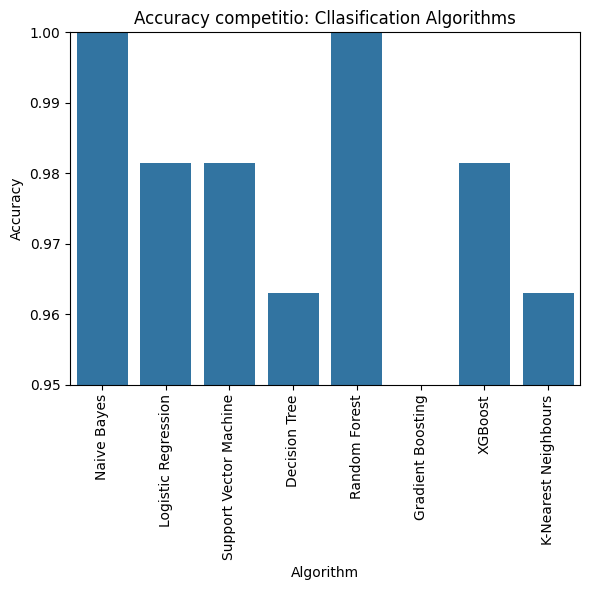

In [11]:
plt.figure(figsize=(6, 6))
sns.barplot(data=results_df, x='Algorithm', y = 'Accuracy')
plt.title('Accuracy competitio: Cllasification Algorithms')
plt.xlabel('Algorithm')
plt.xticks(rotation=90)
plt.ylabel('Accuracy')
plt.ylim(0.95, 1)
plt.tight_layout()
plt.show

Plotting the training time comparison.

<function matplotlib.pyplot.show(close=None, block=None)>

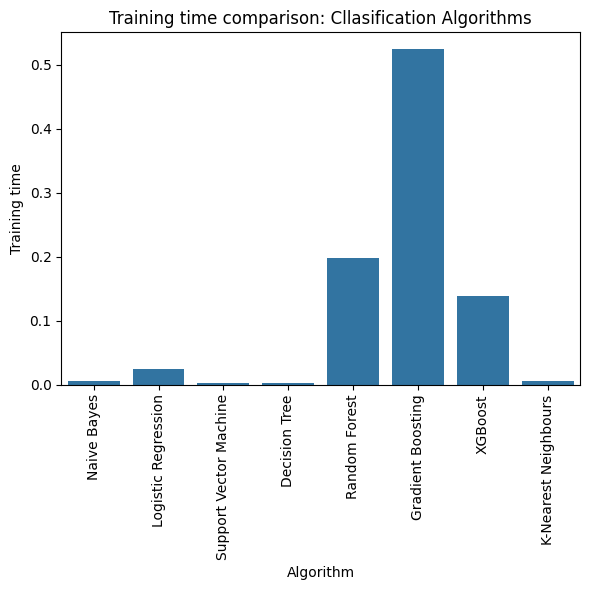

In [12]:
plt.figure(figsize=(6, 6))
sns.barplot(data=results_df, x='Algorithm', y = 'Training time')
plt.title('Training time comparison: Cllasification Algorithms')
plt.xlabel('Algorithm')
plt.xticks(rotation=90)
plt.ylabel('Training time')
plt.tight_layout()
plt.show